# 👩‍⚖️ ⚖️ Machine Learning Court

This submission completes **Case 1 — Prosecution** only. The starter's
Case 1 model and focus-instance code are retained below; the SHAP, LIME,
and prosecution analysis are added afterward.


## ⚖️ Case 1: Loan Denial Dispute – UCI Adult Income Dataset
#### 🔍 Scenario

Jane Dow, a 37-year-old professional woman with a Bachelor's degree and full-time executive role, applied for a premium credit product. The bank’s model—trained to predict income level as a proxy for eligibility—classified her as earning ≤$50K, resulting in denial. She disputes the fairness of the decision.

#### 🟥 Prosecution
Evaluate whether the model’s decision may have been influenced by inappropriate or unfair reasoning. Explore whether the explanation aligns with what should be expected in a fair credit decision.

#### 🟦 Defense
Justify the decision based on the model’s learned patterns. Consider how well the explanation supports the classification and whether similar profiles are treated consistently.


In [1]:
# 📦 Case 1: Loan Approval Prediction (Adult Income Dataset)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load Data
from sklearn.datasets import fetch_openml
try:
    adult = fetch_openml(name='adult', version=2, as_frame=True)
    df = adult.frame
except Exception:
    # Local UCI fallback only for environments where OpenML is unavailable.
    adult_columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
                     'marital-status', 'occupation', 'relationship', 'race', 'sex',
                     'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']
    df = pd.read_csv('adult.data', names=adult_columns, skipinitialspace=True,
                     na_values='?', skip_blank_lines=True)

# Clean and preprocess
df = df.dropna()
df = df.copy()
encoders = {}
label_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()

for col in label_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str).str.strip()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop(["class", "fnlwgt"], axis=1)
y = df["class"].apply(lambda x: 1 if x == encoders['class'].transform(['>50K'])[0] else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train simple RF model
model_adult = RandomForestClassifier(random_state=42)
model_adult.fit(X_train, y_train)
print(classification_report(y_test, model_adult.predict(X_test)))


/Applications/ServBay/package/python/3.13/3.13.3/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/datasets/_openml.py:109: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/list/data_name/adult/limit/2/data_version/2. Retrying...
  warn(


              precision    recall  f1-score   support

           0       0.88      0.91      0.90      4503
           1       0.71      0.65      0.68      1530

    accuracy                           0.84      6033
   macro avg       0.80      0.78      0.79      6033
weighted avg       0.84      0.84      0.84      6033



In [2]:
# 🎯 Focus Instance: Loan Rejection Case (Jane Dow)

jane_encoded = {
    'age': 37,
    'workclass': encoders['workclass'].transform(['Private'])[0],
    'education': encoders['education'].transform(['Bachelors'])[0],
    'marital-status': encoders['marital-status'].transform(['Never-married'])[0],
    'occupation': encoders['occupation'].transform(['Exec-managerial'])[0],
    'relationship': encoders['relationship'].transform(['Not-in-family'])[0],
    'race': encoders['race'].transform(['White'])[0],
    'sex': encoders['sex'].transform(['Female'])[0],
    'hours-per-week': 50,
    'native-country': encoders['native-country'].transform(['United-States'])[0],
    'capital-gain': 0,
    'capital-loss': 0,
    'education-num': 13,
}

jane_df = pd.DataFrame([jane_encoded])
jane_df = jane_df[X_train.columns]
pred = model_adult.predict(jane_df)
print("Prediction for Jane Dow (Loan Eligibility):", "Approved" if pred[0] == 1 else "Denied")


Prediction for Jane Dow (Loan Eligibility): Denied


-----

# Prosecution-related Analysis

## Added analysis: data and model check

The model is predicting historical income (`>$50K`) as a proxy for loan
eligibility. It is not trained on repayment behavior or a real credit
policy, which is central to the prosecution's concern.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import shap
from lime.lime_tabular import LimeTabularExplainer

jane_raw = pd.DataFrame([{
    'age': 37, 'workclass': 'Private', 'education': 'Bachelors',
    'education-num': 13, 'marital-status': 'Never-married',
    'occupation': 'Exec-managerial', 'relationship': 'Not-in-family',
    'race': 'White', 'sex': 'Female', 'capital-gain': 0,
    'capital-loss': 0, 'hours-per-week': 50, 'native-country': 'United-States'
}])

print(f"Dataset used after cleaning: {df.shape[0]:,} rows and {X.shape[1]} model features")
display(y.value_counts(normalize=True).rename('proportion').mul(100).round(1).to_frame())
jane_approval_probability = model_adult.predict_proba(jane_df)[0, 1]
print(f"Jane's P(>$50K / approved): {jane_approval_probability:.1%}")
print("The model receives protected attributes directly: sex and race.")

def encode_applicants(applicants):
    encoded = applicants.copy()
    for column, encoder in encoders.items():
        if column in encoded.columns:
            encoded[column] = encoder.transform(encoded[column].astype(str))
    return encoded[X_train.columns]


Dataset used after cleaning: 30,162 rows and 13 model features


,proportion
class,
0,75.1
1,24.9


Jane's P(>$50K / approved): 23.0%
The model receives protected attributes directly: sex and race.


## XAI method 1: SHAP

The following local SHAP values explain Jane's probability of the
approval (`>$50K`) class. Negative values push her prediction toward
denial; positive values push it toward approval.


,feature,Jane's value,SHAP contribution to P(approved)
6,relationship,Not-in-family,-0.1489
4,marital-status,Never-married,-0.1148
9,capital-gain,0,-0.0296
10,capital-loss,0,-0.0100
8,sex,Female,-0.0093
7,race,White,-0.0050
12,native-country,United-States,0.0027
2,education,Bachelors,0.0106
1,workclass,Private,0.0119
0,age,37,0.0269


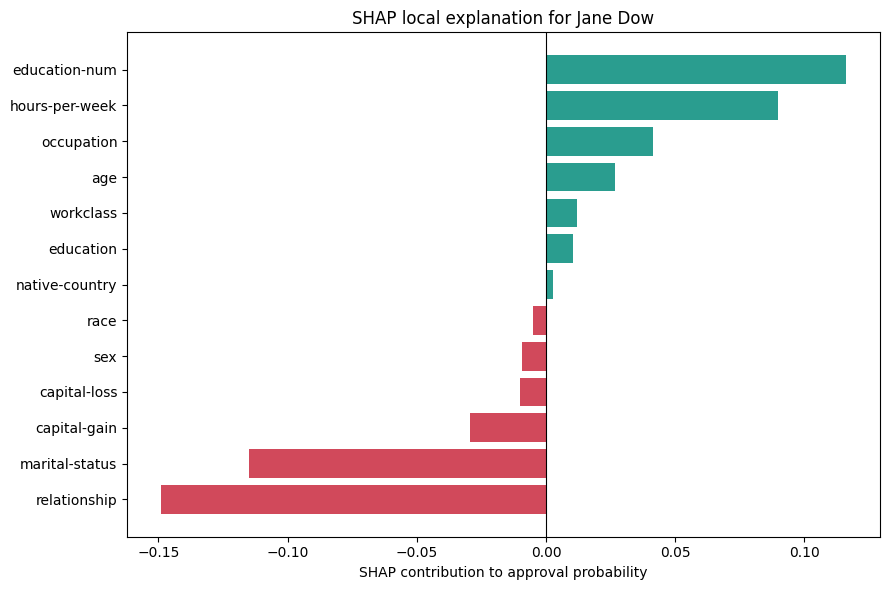

Brief interpretation: relationship is the largest local force toward denial (-0.149); education-num is the largest force toward approval (0.116).


In [ ]:
tree_explainer = shap.TreeExplainer(model_adult)
jane_shap = tree_explainer(jane_df)
approval_shap_values = jane_shap.values[0, :, 1]

shap_table = pd.DataFrame({
    'feature': X_train.columns,
    "Jane's value": jane_raw.iloc[0][X_train.columns].astype(str).values,
    'SHAP contribution to P(approved)': approval_shap_values,
}).sort_values('SHAP contribution to P(approved)')
display(shap_table.round({'SHAP contribution to P(approved)': 4}))

colors = np.where(shap_table['SHAP contribution to P(approved)'] >= 0, '#2a9d8f', '#d1495b')
plt.figure(figsize=(9, 6))
plt.barh(shap_table['feature'], shap_table['SHAP contribution to P(approved)'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('SHAP contribution to approval probability')
plt.title('SHAP local explanation for Jane Dow')
plt.tight_layout()
plt.show()

print(
    f"Brief interpretation: {shap_table.iloc[0]['feature']} is the largest local force toward denial "
    f"({shap_table.iloc[0]['SHAP contribution to P(approved)']:.3f}); "
    f"{shap_table.iloc[-1]['feature']} is the largest force toward approval "
    f"({shap_table.iloc[-1]['SHAP contribution to P(approved)']:.3f})."
)


## XAI method 2: LIME

LIME fits an interpretable local approximation around Jane's record. A
positive weight below supports the denial (`≤$50K`) class.


/Applications/ServBay/package/python/3.13/3.13.3/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,local condition,weight toward denial
0,capital-gain <= 0.00,0.5830
1,hours-per-week > 45.00,-0.0966
2,capital-loss <= 0.00,0.0860
3,marital-status=Never-married,0.0769
4,10.00 < education-num <= 13.00,-0.0599
5,relationship=Not-in-family,0.0566
6,occupation=Exec-managerial,-0.0462
7,sex=Female,0.0207
8,workclass=Private,0.0052
9,education=Bachelors,-0.0042


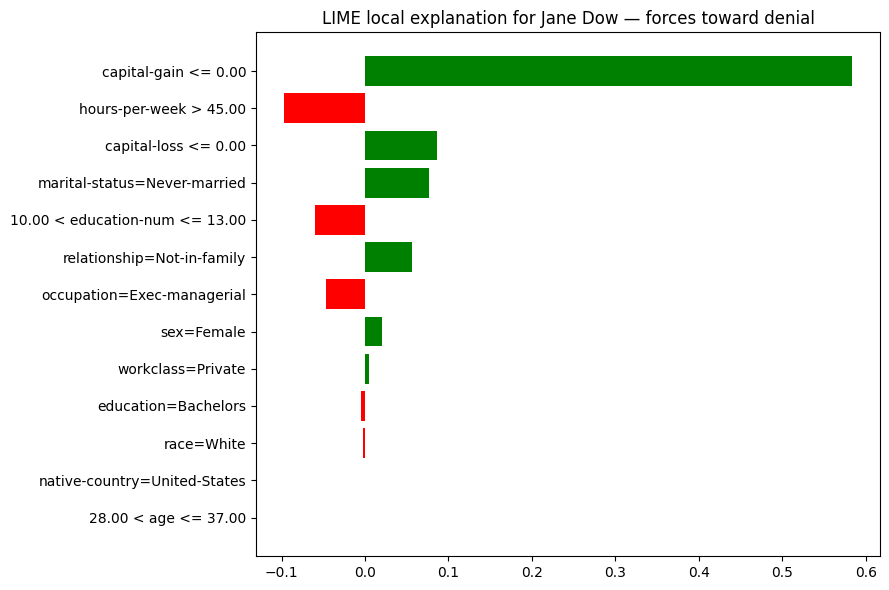

Brief interpretation: LIME's strongest local condition supporting denial is 'capital-gain <= 0.00' (weight 0.583).


In [ ]:
categorical_columns = [column for column in encoders if column not in {'class'} and column in X_train.columns]
categorical_indices = [X_train.columns.get_loc(column) for column in categorical_columns]
categorical_names = {X_train.columns.get_loc(column): list(encoders[column].classes_)
                     for column in categorical_columns}
lime_explainer = LimeTabularExplainer(
    X_train.to_numpy(), feature_names=X_train.columns.tolist(),
    class_names=['≤$50K (Denied)', '>$50K (Approved)'],
    categorical_features=categorical_indices, categorical_names=categorical_names,
    mode='classification', discretize_continuous=True, random_state=42,
)
lime_explanation = lime_explainer.explain_instance(
    jane_df.iloc[0].to_numpy(), model_adult.predict_proba, labels=(0,), num_features=len(X_train.columns)
)
lime_table = pd.DataFrame(lime_explanation.as_list(label=0), columns=['local condition', 'weight toward denial'])
display(lime_table.round({'weight toward denial': 4}))
figure = lime_explanation.as_pyplot_figure(label=0)
figure.set_size_inches(9, 6)
plt.title('LIME local explanation for Jane Dow — forces toward denial')
plt.tight_layout()
plt.show()
print(f"Brief interpretation: LIME's strongest local condition supporting denial is "
      f"'{lime_table.iloc[0]['local condition']}' (weight {lime_table.iloc[0]['weight toward denial']:.3f}).")


## Prosecution exhibit: protected-attribute counterfactual

A model intended for a fair credit decision should not materially alter
its result solely because sex or race changes. This is a one-person
diagnostic, not a complete group-fairness assessment.


In [ ]:
counterfactual_raw = pd.concat([
    jane_raw.assign(scenario='Original: Female, White'),
    jane_raw.assign(sex='Male', scenario='Only sex changed: Male'),
    jane_raw.assign(race='Black', scenario='Only race changed: Black'),
], ignore_index=True)
counterfactual_model = encode_applicants(counterfactual_raw.drop(columns='scenario'))
counterfactual_raw['P(approved)'] = model_adult.predict_proba(counterfactual_model)[:, 1]
counterfactual_raw['change from Jane'] = counterfactual_raw['P(approved)'] - jane_approval_probability
counterfactual_raw['decision @ 0.50'] = np.where(counterfactual_raw['P(approved)'] >= 0.5, 'Approved', 'Denied')
results = counterfactual_raw[['scenario', 'P(approved)', 'change from Jane', 'decision @ 0.50']]
display(results.style.format({'P(approved)': '{:.1%}', 'change from Jane': '{:+.1%}'}))

print(f"Changing only sex changes the approval probability by {results.loc[1, 'change from Jane']:+.1%}.")
print(f"Changing only race changes the approval probability by {results.loc[2, 'change from Jane']:+.1%}.")


,scenario,P(approved),change from Jane,decision @ 0.50
0,"Original: Female, White",23.0%,+0.0%,Denied
1,Only sex changed: Male,13.0%,-10.0%,Denied
2,Only race changed: Black,46.0%,+23.0%,Denied


Changing only sex changes the approval probability by -10.0%.
Changing only race changes the approval probability by +23.0%.


## Prosecution conclusion

Jane is denied even though several characteristics, including her bachelor's degree, executive occupation, and long working hours, push toward a seemingly strong socioeconomic profile. However, those characteristics alone do not establish that the denial is unfair.

The stronger prosecution concern is that the model directly uses protected attributes such as sex and race. SHAP and LIME reveal which features influence Jane's prediction, while the counterfactual test evaluates whether changing only a protected attribute materially changes her predicted approval probability. Such sensitivity would not by itself prove discrimination, but it would raise a fairness concern that warrants broader group-level testing.

More fundamentally, the model predicts whether historical census income exceeds $50K, not whether an applicant is likely to repay a loan. It excludes central measures of creditworthiness such as repayment history, debt, assets, and validated lending criteria. Therefore, even an accurate income classifier may be an inappropriate basis for a credit decision.

The prosecution would therefore argue that this model should not be used as the sole basis for adverse action without validating the target, examining the role of protected and proxy variables, conducting broader fairness testing, and providing meaningful human review.
